In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, RepeatVector, TimeDistributed, Input
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline
sns.set(style="whitegrid")


In [2]:
df = pd.read_csv("../data/processed/merged_enriched.csv", parse_dates=["datetime"])
df.head()


,client_id,value,datetime,hour,day,month,weekday,is_weekend
0,MAC000002,0.263,2012-10-13 00:00:00,0,13,10,5,True
1,MAC000002,0.269,2012-10-13 00:30:00,0,13,10,5,True
2,MAC000002,0.275,2012-10-13 01:00:00,1,13,10,5,True
3,MAC000002,0.256,2012-10-13 01:30:00,1,13,10,5,True
4,MAC000002,0.211,2012-10-13 02:00:00,2,13,10,5,True


In [3]:
client_id = df["client_id"].unique()[0]
df_client = df[df["client_id"] == client_id].copy()
df_client = df_client.sort_values("datetime")

scaler = MinMaxScaler()
df_client["value_scaled"] = scaler.fit_transform(df_client[["value"]])


In [5]:
def create_sequences(data, window_size):
    sequences = []
    for i in range(len(data) - window_size):
        sequences.append(data[i:i+window_size])
    return np.array(sequences)

window_size = 48
sequences = create_sequences(df_client["value_scaled"].values, window_size)
print("Forme des séquences :", sequences.shape)


Forme des séquences : (23855, 48)


### LSTM

In [6]:
X = sequences[:-1]
y = sequences[1:, -1]

X = np.expand_dims(X, axis=2)

In [ ]:
model_lstm = Sequential([
    LSTM(64, activation="relu", input_shape=(window_size, 1)),
    Dense(1)
])
model_lstm.compile(optimizer=Adam(0.001), loss="mse")
model_lstm.fit(X, y, epochs=10, batch_size=32, verbose=1)


Epoch 1/10
746/746 [==============================] - 11s 13ms/step - loss: 0.0046
Epoch 2/10
746/746 [==============================] - 10s 13ms/step - loss: 0.0041
Epoch 3/10
746/746 [==============================] - 11s 15ms/step - loss: 0.0040
Epoch 4/10
746/746 [==============================] - 11s 15ms/step - loss: 0.0039
Epoch 5/10
746/746 [==============================] - 12s 17ms/step - loss: 0.0039
Epoch 6/10
746/746 [==============================] - 13s 17ms/step - loss: 0.0053
Epoch 7/10
746/746 [==============================] - 13s 17ms/step - loss: 0.0039
Epoch 8/10
746/746 [==============================] - 13s 17ms/step - loss: 0.0039
Epoch 9/10
746/746 [==============================] - 13s 18ms/step - loss: 0.0038
Epoch 10/10
746/746 [==============================] - 13s 18ms/step - loss: 0.0038


746/746 [==============================] - 4s 5ms/step


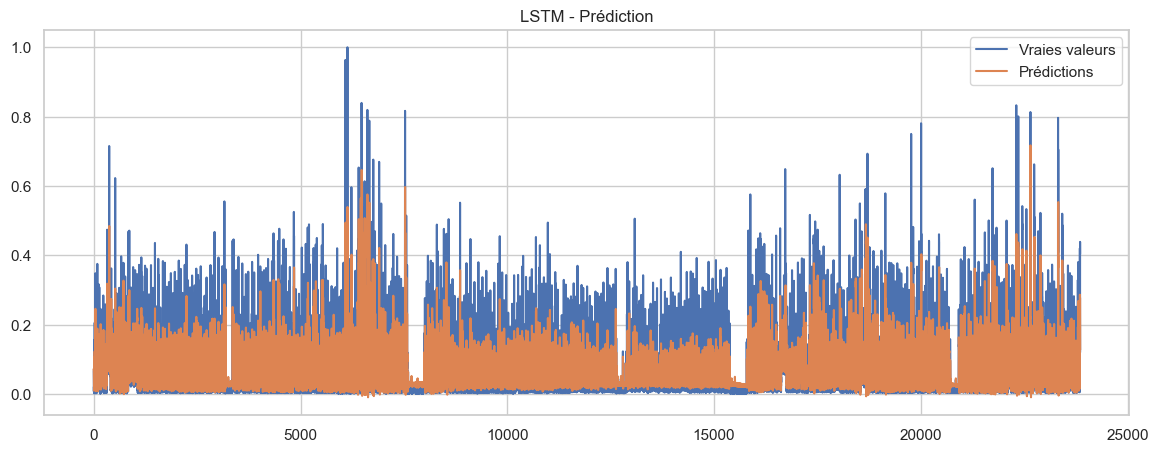

In [7]:
y_pred = model_lstm.predict(X)
y_true = y

plt.figure(figsize=(14, 5))
plt.plot(y_true, label="Vraies valeurs")
plt.plot(y_pred, label="Prédictions")
plt.title("LSTM - Prédiction")
plt.legend()
plt.show()


### Autoencoder

In [8]:
input_layer = Input(shape=(window_size, 1))
encoded = LSTM(64, activation="relu", return_sequences=False)(input_layer)
decoded = RepeatVector(window_size)(encoded)
decoded = LSTM(64, activation="relu", return_sequences=True)(decoded)
output = TimeDistributed(Dense(1))(decoded)

autoencoder = Model(inputs=input_layer, outputs=output)
autoencoder.compile(optimizer="adam", loss="mae")
autoencoder.fit(X, X, epochs=10, batch_size=32, verbose=1)


Epoch 1/10
746/746 [==============================] - 26s 31ms/step - loss: 0.0449
Epoch 2/10
746/746 [==============================] - 25s 34ms/step - loss: 0.0387
Epoch 3/10
746/746 [==============================] - 26s 35ms/step - loss: 0.0447
Epoch 4/10
746/746 [==============================] - 29s 39ms/step - loss: 0.4525
Epoch 5/10
746/746 [==============================] - 30s 41ms/step - loss: 0.0408
Epoch 6/10
746/746 [==============================] - 32s 43ms/step - loss: 0.0373
Epoch 7/10
746/746 [==============================] - 32s 43ms/step - loss: 0.0355
Epoch 8/10
746/746 [==============================] - 30s 40ms/step - loss: 0.0339
Epoch 9/10
746/746 [==============================] - 28s 38ms/step - loss: 0.0326
Epoch 10/10
746/746 [==============================] - 29s 39ms/step - loss: 0.0318


746/746 [==============================] - 9s 12ms/step


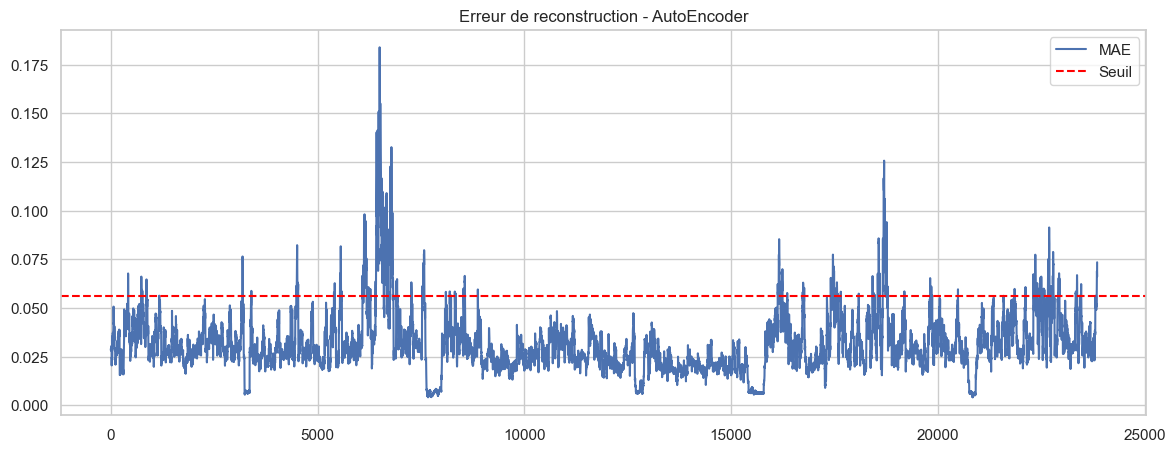

In [9]:
X_pred = autoencoder.predict(X)
mae = np.mean(np.abs(X_pred - X), axis=(1, 2))

threshold = np.percentile(mae, 95)
anomalies = mae > threshold

plt.figure(figsize=(14, 5))
plt.plot(mae, label="MAE")
plt.axhline(threshold, color="red", linestyle="--", label="Seuil")
plt.title("Erreur de reconstruction - AutoEncoder")
plt.legend()
plt.show()


### One-Class SVM, Isolation Forest

In [ ]:
isoforest = IsolationForest(contamination=0.05)
ocsvm = OneClassSVM(nu=0.05)

df_client["anomaly_isoforest"] = isoforest.fit_predict(X.squeeze())
df_client["anomaly_ocsvm"] = ocsvm.fit_predict(X.squeeze())

# Visualisation
plt.figure(figsize=(14, 5))
plt.plot(df_client["datetime"].iloc[window_size:-1], y_true, label="Valeurs")
plt.scatter(df_client["datetime"].iloc[window_size:-1][df_client["anomaly_isoforest"]==-1],
            y_true[df_client["anomaly_isoforest"]==-1], color="red", label="Anomalies IF")
plt.title("Anomalies Isolation Forest")
plt.legend()
plt.show()
